# Hybrid Quantum Neural Network (HQNN)

This tutorial demonstrates how to build a **Hybrid Quantum Neural Network** (HQNN) on Fashion-MNIST that combines classical neural network layers with a quantum variational circuit layer. The quantum layer is defined using Qamomile's `@qkernel` API, transpiled to Qiskit, and integrated into a PyTorch training pipeline via the parameter shift rule.

## Architecture

The entire model — CNN feature extractor, quantum layer, and fusion classifier — is trained **end-to-end from scratch**:

```
Input Image → CNN → π·σ(·) → Quantum Layer → [CNN feats, Q output] → Classifier → Output
```

The fusion classifier takes both classical CNN features and quantum expectation values, allowing the CNN and quantum layer to learn cooperatively from the start.

## Imports and Setup

In [1]:
import math

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

import qamomile.circuit as qmc
import qamomile.observable as qmo
from qamomile.qiskit import QiskitTranspiler
from qamomile.qiskit.observable import hamiltonian_to_sparse_pauli_op
from qiskit.primitives import StatevectorEstimator

In [2]:
N_QUBITS = 4
N_LAYERS = 2
N_WEIGHTS_PER_LAYER = N_QUBITS * 3  # RZ, RY, RZ per qubit
N_WEIGHTS = N_LAYERS * N_WEIGHTS_PER_LAYER

print(f"Qubits: {N_QUBITS}, Layers: {N_LAYERS}, Trainable weights: {N_WEIGHTS}")

Qubits: 4, Layers: 2, Trainable weights: 24


## Define the Variational Ansatz with @qkernel

We define a parameterized quantum circuit using Qamomile's `@qkernel` decorator.
The circuit consists of:

1. **Angle encoding**: Each input feature is encoded as an RY rotation on the corresponding qubit.
2. **Variational layers**: Each layer applies RZ–RY–RZ rotations with trainable weights, followed by a CNOT entanglement ladder.

The circuit returns measurement results as classical bits.

In [3]:
@qmc.qkernel
def variational_ansatz(
    n_qubits: qmc.UInt,
    n_layers: qmc.UInt,
    inputs: qmc.Vector[qmc.Float],
    weights: qmc.Vector[qmc.Float],
) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(n_qubits, name="q")

    # Angle encoding: embed classical features as RY rotations
    for i in qmc.range(n_qubits):
        q[i] = qmc.ry(q[i], inputs[i])

    # Variational layers
    for l in qmc.range(n_layers):
        base = l * n_qubits * 3
        # RZ-RY-RZ single-qubit rotations
        for i in qmc.range(n_qubits):
            q[i] = qmc.rz(q[i], weights[base + i])
        for i in qmc.range(n_qubits):
            q[i] = qmc.ry(q[i], weights[base + n_qubits + i])
        for i in qmc.range(n_qubits):
            q[i] = qmc.rz(q[i], weights[base + n_qubits * 2 + i])

        # CNOT entanglement ladder
        for i in qmc.range(n_qubits - 1):
            q[i], q[i + 1] = qmc.cx(q[i], q[i + 1])

    return qmc.measure(q)

Let's visualize the circuit structure:

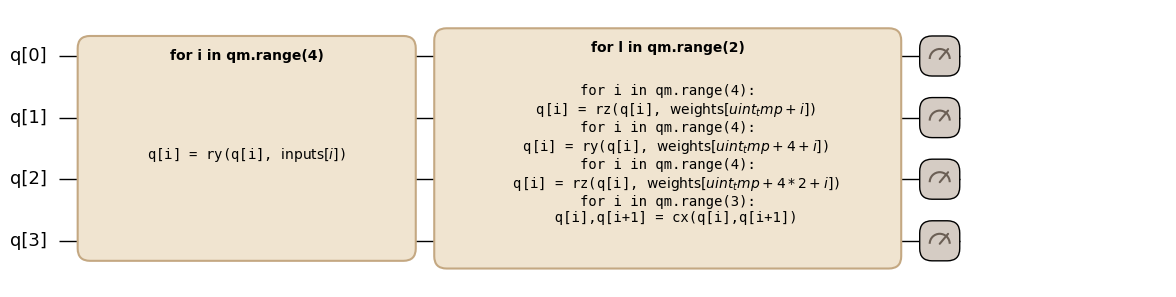

In [4]:
variational_ansatz.draw(
    n_qubits=N_QUBITS,
    n_layers=N_LAYERS,
    inputs=[0.1] * N_QUBITS,
    weights=[0.1] * N_WEIGHTS,
)

## Transpile to Qiskit

We transpile the `@qkernel` to a Qiskit `QuantumCircuit`, keeping `inputs` and `weights` as symbolic parameters that can be bound at runtime.

In [5]:
transpiler = QiskitTranspiler()

executable = transpiler.transpile(
    variational_ansatz,
    bindings={"n_qubits": N_QUBITS, "n_layers": N_LAYERS},
    parameters=["inputs", "weights"],
)

# Get the underlying Qiskit circuit (with symbolic parameters)
qiskit_circuit = executable.get_first_circuit()
param_metadata = executable.compiled_quantum[0].parameter_metadata

print(f"Circuit depth: {qiskit_circuit.depth()}")
print(f"Number of parameters: {qiskit_circuit.num_parameters}")

Circuit depth: 13
Number of parameters: 28


## Define Observables

For each qubit we measure the expectation value $\langle Z_i \rangle$.
These expectation values become the output of the quantum layer.

In [6]:
# Build one Hamiltonian per qubit: <Z_i>
# We specify num_qubits to match the circuit size
observables = []
for i in range(N_QUBITS):
    h = qmo.Hamiltonian(num_qubits=N_QUBITS)
    h.add_term((qmo.PauliOperator(qmo.Pauli.Z, i),), 1.0)
    observables.append(h)

# Convert to Qiskit SparsePauliOp
qiskit_obs = [hamiltonian_to_sparse_pauli_op(obs) for obs in observables]

# Remove measurements from the circuit for expectation value estimation
ansatz_no_meas = qiskit_circuit.remove_final_measurements(inplace=False)

estimator = StatevectorEstimator()

## Quantum Forward Pass

The forward pass binds concrete values to the circuit parameters and evaluates $\langle Z_i \rangle$ for each qubit using the `StatevectorEstimator`.

In [7]:
def expand_bindings(bindings: dict) -> dict:
    """Expand vector bindings to indexed format for param_metadata."""
    result = {}
    for key, value in bindings.items():
        if isinstance(value, (list, tuple, np.ndarray)):
            for i, v in enumerate(value):
                result[f"{key}[{i}]"] = v
        else:
            result[key] = value
    return result


def quantum_forward(input_vals: np.ndarray, weight_vals: np.ndarray) -> np.ndarray:
    """Evaluate <Z_i> for each qubit given inputs and weights.

    Args:
        input_vals: Feature values, shape (N_QUBITS,).
        weight_vals: Trainable weights, shape (N_WEIGHTS,).

    Returns:
        Expectation values, shape (N_QUBITS,).
    """
    indexed = expand_bindings({"inputs": list(input_vals), "weights": list(weight_vals)})
    binding_dict = param_metadata.to_binding_dict(indexed)
    bound_circuit = ansatz_no_meas.assign_parameters(binding_dict)

    # Batch all observable evaluations in a single estimator call
    pubs = [(bound_circuit, obs) for obs in qiskit_obs]
    job = estimator.run(pubs)
    results = job.result()

    return np.array([float(r.data.evs) for r in results])

In [8]:
# Quick test: random inputs and weights
rng = np.random.default_rng(42)
test_inputs = rng.uniform(-np.pi, np.pi, N_QUBITS)
test_weights = rng.uniform(-np.pi, np.pi, N_WEIGHTS)

expvals = quantum_forward(test_inputs, test_weights)
print("Expectation values:", expvals)

Expectation values: [ 0.00909923  0.25403499  0.31838452 -0.06170293]


## Parameter Shift Rule for Gradients

To train the quantum layer with PyTorch's autograd, we need gradients of the expectation values with respect to every parameter. The **parameter shift rule** gives us an exact gradient formula for gates of the form $e^{-i\theta G/2}$:

$$
\frac{\partial}{\partial \theta_k} \langle Z_i \rangle
= \frac{1}{2} \Big[
    \langle Z_i \rangle\big|_{\theta_k + \pi/2}
  - \langle Z_i \rangle\big|_{\theta_k - \pi/2}
\Big]
$$

We implement this as a custom `torch.autograd.Function` so that PyTorch can backpropagate through the quantum layer.

In [9]:
SHIFT = math.pi / 2


class QuantumFunction(torch.autograd.Function):
    """Custom autograd function bridging PyTorch and the quantum circuit."""

    @staticmethod
    def forward(ctx, inputs: torch.Tensor, weights: torch.Tensor) -> torch.Tensor:
        ctx.save_for_backward(inputs, weights)
        # Evaluate the circuit for each sample in the batch
        batch_results = []
        weights_np = weights.detach().cpu().numpy()
        for inp in inputs:
            expvals = quantum_forward(inp.detach().cpu().numpy(), weights_np)
            batch_results.append(expvals)
        return torch.tensor(np.array(batch_results), dtype=inputs.dtype, device=inputs.device)

    @staticmethod
    def backward(ctx, grad_output: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        inputs, weights = ctx.saved_tensors
        weights_np = weights.detach().cpu().numpy()

        grad_inputs = torch.zeros_like(inputs)
        grad_weights = torch.zeros(weights.shape[0], dtype=weights.dtype, device=weights.device)

        for b, inp in enumerate(inputs):
            inp_np = inp.detach().cpu().numpy()
            g_out = grad_output[b].detach().cpu().numpy()  # shape (N_QUBITS,)

            # Gradient w.r.t. weights
            for k in range(len(weights_np)):
                shifted_plus = weights_np.copy()
                shifted_plus[k] += SHIFT
                shifted_minus = weights_np.copy()
                shifted_minus[k] -= SHIFT

                fwd_plus = quantum_forward(inp_np, shifted_plus)
                fwd_minus = quantum_forward(inp_np, shifted_minus)
                param_grad = (fwd_plus - fwd_minus) / 2.0  # shape (N_QUBITS,)

                grad_weights[k] += np.dot(g_out, param_grad)

            # Gradient w.r.t. inputs
            for k in range(len(inp_np)):
                shifted_plus = inp_np.copy()
                shifted_plus[k] += SHIFT
                shifted_minus = inp_np.copy()
                shifted_minus[k] -= SHIFT

                fwd_plus = quantum_forward(shifted_plus, weights_np)
                fwd_minus = quantum_forward(shifted_minus, weights_np)
                input_grad = (fwd_plus - fwd_minus) / 2.0

                grad_inputs[b, k] = np.dot(g_out, input_grad)

        return grad_inputs, grad_weights

## Quantum Layer as a PyTorch Module

We wrap the autograd function into a standard `nn.Module` so it can be composed with other layers.

In [10]:
class QLayer(nn.Module):
    """PyTorch module wrapping a Qamomile variational circuit."""

    def __init__(self, n_weights: int):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(n_weights) * 0.1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return QuantumFunction.apply(x, self.weights)

## Prepare Data (Fashion-MNIST)

We use a subset of [Fashion-MNIST](https://github.com/zalandoresearch/fashion-mnist) with 4 visually distinct classes. Fashion-MNIST consists of 28×28 grayscale clothing images.

To keep computation time reasonable, we select 4 classes (T-shirt, Trouser, Sandal, Bag) with 60 training and 30 test samples per class.

In [11]:
import os

N_CLASSES = 4
SELECTED_CLASSES = [0, 1, 5, 8]  # T-shirt, Trouser, Sandal, Bag
CLASS_NAMES = ["T-shirt", "Trouser", "Sandal", "Bag"]
N_TRAIN_PER_CLASS = 60
N_TEST_PER_CLASS = 30

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,)),
])

# Use a persistent cache directory to avoid re-downloading
_data_root = os.path.join(os.path.expanduser("~"), ".cache", "fashion_mnist")
full_train = datasets.FashionMNIST(
    root=_data_root, train=True, download=True, transform=transform
)
full_test = datasets.FashionMNIST(
    root=_data_root, train=False, download=True, transform=transform
)


def subset_dataset(dataset, classes, n_per_class):
    """Extract a random subset from the specified classes."""
    images, labels = [], []
    rng_data = np.random.default_rng(0)
    # Use dataset.targets to find indices without loading/transforming all images
    targets = dataset.targets
    if isinstance(targets, torch.Tensor):
        targets = targets.numpy()
    else:
        targets = np.array(targets)
    for new_label, orig_label in enumerate(classes):
        class_indices = np.where(targets == orig_label)[0]
        chosen = rng_data.choice(class_indices, size=n_per_class, replace=False)
        for idx in chosen:
            img, _ = dataset[int(idx)]
            images.append(img)
            labels.append(new_label)
    return torch.stack(images), torch.tensor(labels)


X_train, y_train = subset_dataset(full_train, SELECTED_CLASSES, N_TRAIN_PER_CLASS)
X_test, y_test = subset_dataset(full_test, SELECTED_CLASSES, N_TEST_PER_CLASS)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Classes: {CLASS_NAMES}")

Train: torch.Size([240, 1, 28, 28]), Test: torch.Size([120, 1, 28, 28])
Classes: ['T-shirt', 'Trouser', 'Sandal', 'Bag']


## End-to-End Hybrid Model

We define the full hybrid model and train it **end-to-end from scratch**. The CNN feature extractor and quantum layer learn cooperatively — gradients flow from the loss through the fusion classifier, through the quantum layer (via parameter shift rule), and back into the CNN.

```
Input Image → [CNN Feature Extractor] → π·σ(·) → [Quantum Layer] → [CNN feats, Q output] → [Classifier] → Output
```

- **Sigmoid scaling**: $\pi \cdot \sigma(\cdot)$ maps CNN outputs to $(0, \pi)$, keeping angles bounded and avoiding wrap-around.
- **Fusion classifier**: Concatenation of `[CNN features, quantum outputs]` gives the classifier access to both classical and quantum representations.

In [12]:
class EndToEndHybridHQNN(nn.Module):
    """
    End-to-end hybrid model trained from scratch.
    Image -> CNN features -> Quantum layer -> Classifier

    The fusion classifier takes [classical features, quantum outputs]
    giving the model access to both representations.
    """

    def __init__(self, n_qubits: int, n_weights: int, n_classes: int):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(1, 4, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(4, 4, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(7 * 7 * 4, n_qubits),
        )
        self.qlayer = QLayer(n_weights)
        self.classifier = nn.Linear(n_qubits * 2, n_classes)

    def forward(self, x: torch.Tensor):
        # CNN features as quantum layer input angles
        feats = math.pi * torch.sigmoid(self.feature_extractor(x))   # shape: (B, N_QUBITS)
        q_out = self.qlayer(feats)                                   # shape: (B, N_QUBITS)

        fused = torch.cat([feats, q_out], dim=1)                     # shape: (B, 2*N_QUBITS)
        logits = self.classifier(fused)
        return logits, feats, q_out


EPOCHS = 10
BATCH_SIZE = 4

torch.manual_seed(42)
hybrid_model = EndToEndHybridHQNN(N_QUBITS, N_WEIGHTS, N_CLASSES)

optimizer = torch.optim.Adam(hybrid_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

train_losses = []
test_accs = []

print(f"=== End-to-End Training ({EPOCHS} epochs) ===")
for epoch in range(EPOCHS):
    perm = torch.randperm(len(X_train))
    X_shuf, y_shuf = X_train[perm], y_train[perm]

    epoch_loss = 0.0
    total = 0

    for i in range(0, len(X_shuf), BATCH_SIZE):
        xb = X_shuf[i : i + BATCH_SIZE]
        yb = y_shuf[i : i + BATCH_SIZE]

        optimizer.zero_grad()
        logits, feats, q_out = hybrid_model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        total += len(yb)

    avg_loss = epoch_loss / max(1, math.ceil(total / BATCH_SIZE))
    train_losses.append(avg_loss)

    with torch.no_grad():
        test_logits, _, _ = hybrid_model(X_test)
        test_acc = (test_logits.argmax(1) == y_test).float().mean().item()
        test_accs.append(test_acc)

    print(f"  Epoch {epoch + 1}/{EPOCHS}  loss={avg_loss:.4f}  test_acc={test_acc:.2%}")

=== End-to-End Training (10 epochs) ===


  Epoch 1/10  loss=1.2718  test_acc=79.17%


  Epoch 2/10  loss=0.7916  test_acc=96.67%


  Epoch 3/10  loss=0.5905  test_acc=95.00%


  Epoch 4/10  loss=0.4901  test_acc=93.33%


...

  Epoch 6/10  loss=0.3795  test_acc=93.33%


  Epoch 7/10  loss=0.3432  test_acc=94.17%


  Epoch 8/10  loss=0.2928  test_acc=94.17%


  Epoch 9/10  loss=0.2730  test_acc=96.67%


  Epoch 10/10  loss=0.2620  test_acc=96.67%


In [13]:
# Verify gradients flow to both CNN and quantum layer
xb = X_train[:BATCH_SIZE]
yb = y_train[:BATCH_SIZE]

optimizer.zero_grad()
logits, feats, q_out = hybrid_model(xb)
loss = criterion(logits, yb)
loss.backward()

print("feature_extractor first conv grad mean:",
      hybrid_model.feature_extractor[0].weight.grad.abs().mean().item())
print("quantum weights grad mean:",
      hybrid_model.qlayer.weights.grad.abs().mean().item())

optimizer.zero_grad()

feature_extractor first conv grad mean: 0.08279561996459961
quantum weights grad mean: 0.009317319840192795


## Evaluation

In [14]:
with torch.no_grad():
    q_logits, F_test_e2e, q_outputs = hybrid_model(X_test)
    preds = q_logits.argmax(1)
    quantum_acc = (preds == y_test).float().mean().item()

print(f"End-to-end quantum model accuracy: {quantum_acc:.2%}")
print()

for c in range(N_CLASSES):
    mask = y_test == c
    class_acc = (preds[mask] == y_test[mask]).float().mean().item()
    print(f"  {CLASS_NAMES[c]}: {class_acc:.2%}")

End-to-end quantum model accuracy: 96.67%

  T-shirt: 90.00%
  Trouser: 100.00%
  Sandal: 100.00%
  Bag: 96.67%


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (a) Learning curves
ax = axes[0]
epochs_range = range(1, EPOCHS + 1)
ax.plot(epochs_range, train_losses, "o-", color="C3", label="Train loss")
ax.plot(epochs_range, test_accs, "s-", color="C0", label="Test accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss / Accuracy")
ax.set_title("Learning Curves")
ax.legend(fontsize=8)

# (b) Confusion matrix
conf = np.zeros((N_CLASSES, N_CLASSES), dtype=int)
for t, p in zip(y_test.numpy(), preds.numpy()):
    conf[t, p] += 1
axes[1].imshow(conf, cmap="Blues")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
axes[1].set_title("Confusion Matrix")
axes[1].set_xticks(range(N_CLASSES))
axes[1].set_yticks(range(N_CLASSES))
axes[1].set_xticklabels(CLASS_NAMES, fontsize=7, rotation=45)
axes[1].set_yticklabels(CLASS_NAMES, fontsize=7)
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        axes[1].text(
            j, i, str(conf[i, j]), ha="center", va="center",
            color="white" if conf[i, j] > conf.max() / 2 else "black",
        )

# (c) Sample images with predictions
n_show = min(8, len(X_test))
sample_imgs = X_test[:n_show, 0].numpy()
combined = np.concatenate(sample_imgs, axis=1)
axes[2].imshow(combined, cmap="gray", aspect="auto")
for i in range(n_show):
    color = "lime" if preds[i] == y_test[i] else "red"
    axes[2].text(
        28 * i + 14, -1.5,
        CLASS_NAMES[preds[i].item()],
        ha="center", va="bottom", fontsize=7, color=color,
    )
    axes[2].text(
        28 * i + 14, 29,
        CLASS_NAMES[y_test[i].item()],
        ha="center", va="top", fontsize=7,
    )
axes[2].set_title("Sample Predictions (green=correct, red=wrong)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

/var/folders/x9/z9h0851n643d8wc3j2v8frv40000gn/T/ipykernel_40599/2214683661.py:53: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
